In [1]:
pip install numpy opencv-python torch matplotlib

In [3]:
import numpy as np
import cv2
import time

def hist_eq_cpu(img):
    hist = np.bincount(img.flatten(), minlength=256)
    pdf = hist / np.sum(hist)
    cdf = np.cumsum(pdf)
    cdf_normalized = (255 * cdf).astype(np.uint8)
    return cdf_normalized[img]

img = cv2.imread("WBB5.jpg", 0)

start = time.time()
out_cpu = hist_eq_cpu(img)
cpu_time = time.time() - start

print("CPU Time:", cpu_time)

CPU Time: 0.026758193969726562


In [4]:
import torch
import time

def hist_eq_gpu(img):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    img_t = torch.tensor(img, device=device, dtype=torch.int64)

    hist = torch.bincount(img_t.flatten(), minlength=256).float()
    pdf = hist / hist.sum()
    cdf = torch.cumsum(pdf, dim=0)

    cdf_scaled = (255 * cdf).clamp(0, 255).long()

    out = cdf_scaled[img_t]
    return out.cpu().numpy()

start = time.time()
out_gpu = hist_eq_gpu(img)
gpu_time = time.time() - start

print("GPU Time:", gpu_time)

GPU Time: 1.8222260475158691


In [5]:
start = time.time()
out_cv = cv2.equalizeHist(img)
cv_time = time.time() - start

print("OpenCV Time:", cv_time)

OpenCV Time: 0.025017738342285156


In [6]:
print("\n=== PERFORMANCE COMPARISON ===")
print(f"CPU Time     : {cpu_time:.6f}s")
print(f"GPU Time     : {gpu_time:.6f}s")
print(f"OpenCV Time  : {cv_time:.6f}s")

print(f"GPU Speedup over CPU: {cpu_time/gpu_time:.2f}x")


=== PERFORMANCE COMPARISON ===
CPU Time     : 0.026758s
GPU Time     : 1.822226s
OpenCV Time  : 0.025018s
GPU Speedup over CPU: 0.01x


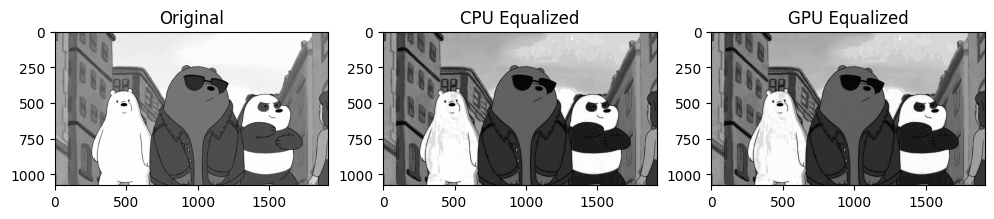

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img, cmap='gray')

plt.subplot(1,3,2)
plt.title("CPU Equalized")
plt.imshow(out_cpu, cmap='gray')

plt.subplot(1,3,3)
plt.title("GPU Equalized")
plt.imshow(out_gpu, cmap='gray')

plt.show()

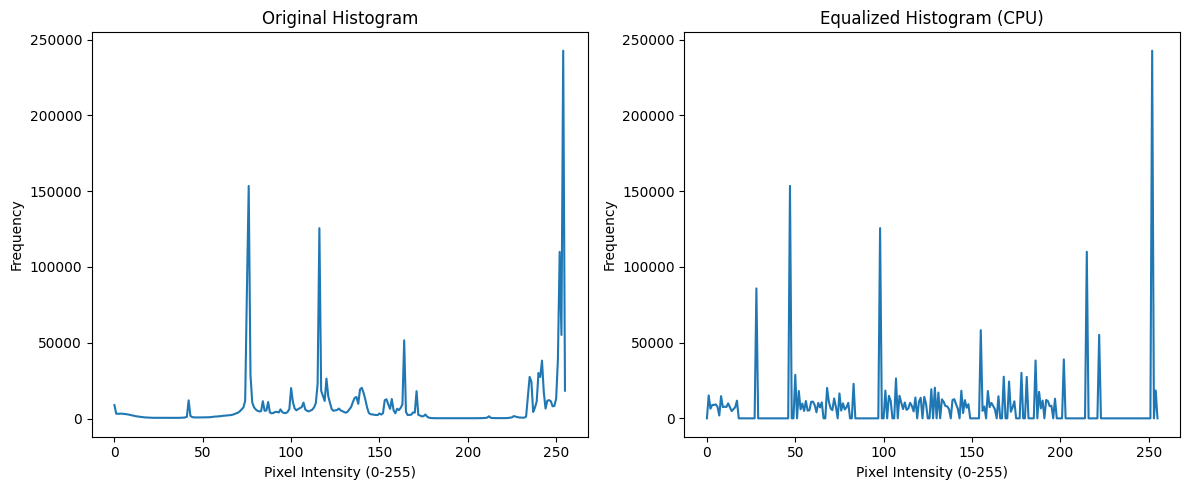

In [8]:
# 📊 7. Histogram Visualization

def plot_histogram(img, title):
    hist = np.bincount(img.flatten(), minlength=256)
    plt.plot(hist)
    plt.title(title)
    plt.xlabel("Pixel Intensity (0-255)")
    plt.ylabel("Frequency")

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_histogram(img, "Original Histogram")

plt.subplot(1,2,2)
plot_histogram(out_cpu, "Equalized Histogram (CPU)")

plt.tight_layout()
plt.show()

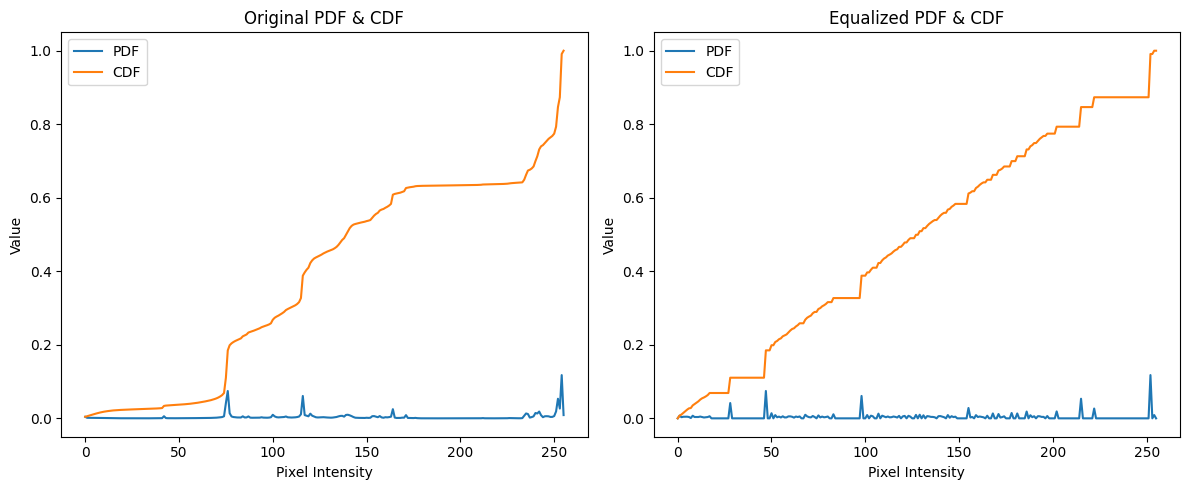

In [9]:
# 📈 8. PDF and CDF Visualization

def plot_pdf_cdf(img, title_prefix):
    hist = np.bincount(img.flatten(), minlength=256)
    pdf = hist / np.sum(hist)
    cdf = np.cumsum(pdf)

    plt.plot(pdf, label="PDF")
    plt.plot(cdf, label="CDF")
    plt.title(title_prefix)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Value")
    plt.legend()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_pdf_cdf(img, "Original PDF & CDF")

plt.subplot(1,2,2)
plot_pdf_cdf(out_cpu, "Equalized PDF & CDF")

plt.tight_layout()
plt.show()